<table align="left">
  <td>
    <a href="https://colab.research.google.com/github/twyncoder/tf-handson-tcb/blob/main/L00_IntroDNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>
  </td>
</table>

# Redes de Aprendizaje Profundo básicas con Keras y Tensorflow.
## *Deep Neural Networks (DNN) para clasificación multi-clase*

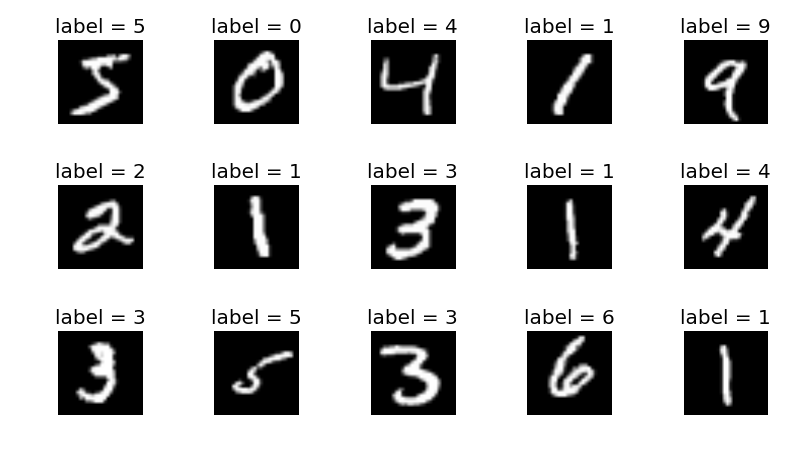

## 0. Preparación del entorno y comprobación de requisitos

In [1]:
# Common imports
import os
import pandas as pd
import numpy as np
import sklearn
import tensorflow as tf
from tensorflow import keras

# To plot pretty figures
%matplotlib inline
import matplotlib as mpl
import matplotlib.pyplot as plt
mpl.rc('axes', labelsize=14)
mpl.rc('xtick', labelsize=12)
mpl.rc('ytick', labelsize=12)

# Where to save the figures
PROJECT_ROOT_DIR = "."
IMAGES_PATH = os.path.join(PROJECT_ROOT_DIR, "images")
os.makedirs(IMAGES_PATH, exist_ok=True)

def save_fig(fig_name, tight_layout=True, fig_extension="png", resolution=300):
    path = os.path.join(IMAGES_PATH, fig_name + "." + fig_extension)
    print("Saving figure", fig_name)
    if tight_layout:
        plt.tight_layout()
    plt.savefig(path, format=fig_extension, dpi=resolution)

### Información de versiones

In [3]:
tf.__version__

'2.10.1'

### Comprobar si disponemos de una GPU

In [4]:
tf.config.list_physical_devices('GPU')

[]

## 1. Inspeccionar los datos y crear subconjuntos train, test, validation

In [5]:
mnist = keras.datasets.mnist
(X_train_full, y_train_full), (X_test, y_test) = mnist.load_data()

11490434/11490434 [==============================] - 1s 0us/step


In [6]:
print(X_train_full.shape)
print(X_test.shape)

(60000, 28, 28)
(10000, 28, 28)


In [7]:
print(np.unique(y_train_full))

[0 1 2 3 4 5 6 7 8 9]


### Crear subconjunto de datos para validación

In [8]:
from sklearn.model_selection import train_test_split
X_train, X_valid, y_train, y_valid = train_test_split(X_train_full,y_train_full,train_size=55000,shuffle=False)
print(X_train.shape)

(55000, 28, 28)


### Normalizar las entradas

In [9]:
print(X_train[0])

[[  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   3  18  18  18 126 136
  175  26 166 255 247 127   0   0   0   0]
 [  0   0   0   0   0   0   0   0  30  36  94 154 170 253 253 253 253 253
  225 172 253 242 195  64   0   0   0   0]
 [  0   0   0   0   0   0   0  49 238 253 253 253 253 253 253 253 253 251
   93  82  82  56  39   0   0   0   0   0]
 [  0   0   0   0   0   0   0  18 219 253 253 253 253 253 198 18

In [10]:
# SOLUTION
X_train = X_train/255.
X_valid = X_valid/255.
X_test  = X_test/255.

### Examinar los datos

Clase:  5


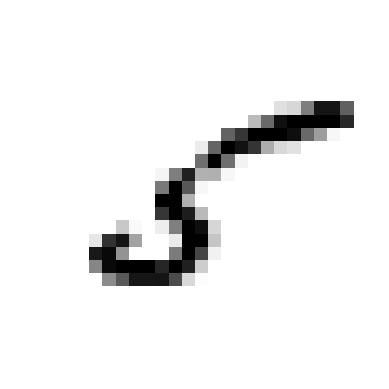

In [13]:
N = 11
plt.imshow(X_train[N], cmap="binary")
plt.axis('off')
print("Clase: ", y_train[N])

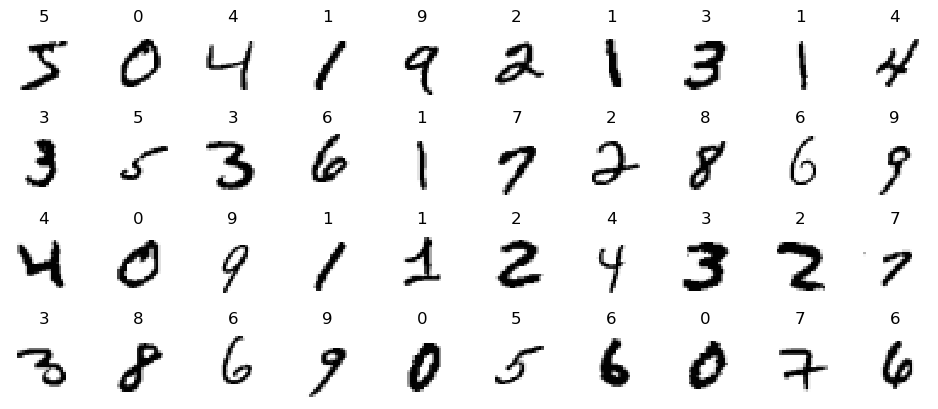

In [14]:
# PRIVATE
n_rows = 4
n_cols = 10
plt.figure(figsize=(n_cols * 1.2, n_rows * 1.2))
for row in range(n_rows):
    for col in range(n_cols):
        index = n_cols * row + col
        plt.subplot(n_rows, n_cols, index + 1)
        plt.imshow(X_train[index], cmap="binary", interpolation="nearest")
        plt.axis('off')
        plt.title(y_train[index], fontsize=12)
plt.subplots_adjust(wspace=0.2, hspace=0.5)
plt.show()

## 2. Definir una red neuronal

#### Con una capa oculta (swallow network)

In [16]:
model = keras.models.Sequential()
model.add(keras.layers.Flatten(input_shape=[28, 28])) # aplana
model.add(keras.layers.Dense(784, activation="sigmoid")) # capa de 784 de neuronas
model.add(keras.layers.Dense(10, activation="softmax")) # capa de 10 neuronas
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 flatten (Flatten)           (None, 784)               0         
                                                                 
 dense (Dense)               (None, 784)               615440    
                                                                 
 dense_1 (Dense)             (None, 10)                7850      
                                                                 
Total params: 623,290
Trainable params: 623,290
Non-trainable params: 0
_________________________________________________________________


In [17]:
model.compile(loss="sparse_categorical_crossentropy", # nuestras etiquetas son numeros enteros, no podemos usar one hot, por eso hacemos una dispersion
              optimizer="sgd",
              metrics=["accuracy"])

## 3. Entrenar red neuronal

In [18]:
history = model.fit(X_train, y_train, epochs=15,
                    validation_data=(X_valid, y_valid))

Epoch 1/15
1719/1719 [==============================] - 9s 5ms/step - loss: 1.3232 - accuracy: 0.7027 - val_loss: 0.7098 - val_accuracy: 0.8644
Epoch 2/15
1719/1719 [==============================] - 9s 5ms/step - loss: 0.6423 - accuracy: 0.8491 - val_loss: 0.4555 - val_accuracy: 0.8988
Epoch 3/15
1719/1719 [==============================] - 8s 5ms/step - loss: 0.4972 - accuracy: 0.8716 - val_loss: 0.3730 - val_accuracy: 0.9108
Epoch 4/15
1719/1719 [==============================] - 9s 5ms/step - loss: 0.4369 - accuracy: 0.8820 - val_loss: 0.3314 - val_accuracy: 0.9142
Epoch 5/15
1719/1719 [==============================] - 8s 5ms/step - loss: 0.4030 - accuracy: 0.8880 - val_loss: 0.3080 - val_accuracy: 0.9178
Epoch 6/15
1719/1719 [==============================] - 8s 5ms/step - loss: 0.3812 - accuracy: 0.8922 - val_loss: 0.2952 - val_accuracy: 0.9202
Epoch 7/15
1719/1719 [==============================] - 8s 5ms/step - loss: 0.3656 - accuracy: 0.8965 - val_loss: 0.2884 - val_accuracy:

In [ ]:
# las imagenes las voy metiendo por lotes (batches), de ahi el 1719 --> steps=55000/32=1732

#### Visualizando gráficamente la evolución del entrenamiento

In [19]:
pdhist = pd.DataFrame(history.history)

In [20]:
pdhist.head() # head imprime las primeras posiciones

,loss,accuracy,val_loss,val_accuracy
0,1.323176,0.702655,0.709818,0.8644
1,0.642270,0.849127,0.455528,0.8988
2,0.497168,0.871582,0.372984,0.9108
3,0.436913,0.882036,0.331368,0.9142
4,0.403043,0.888000,0.307962,0.9178


Saving figure T01_mnist_simple_dnn


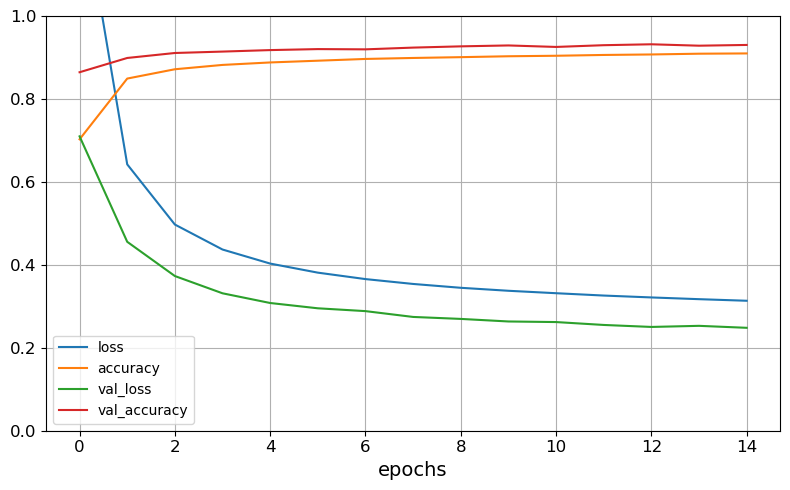

In [21]:
pd.DataFrame(history.history).plot(figsize=(8, 5))
plt.grid(True)
plt.gca().set_ylim(0, 1)
plt.xlabel("epochs")
save_fig("T01_mnist_simple_dnn")
plt.show()

In [22]:
# la curva del val_loss tiene menos epocas (se evalua menos veces) por eso se ve como con picos
# el loss va bajando porque hay un optimizador que va buscando el minimo de una funcion de perdidas: se actualizan los parametros en cada iteracion segun una formula

## 3. Test

#### Midiendo el rendimiento con el set de test

In [23]:
model.evaluate(X_test, y_test) # prueba sobre todo el conjunto de test de 10000 imagenes que teniamos

313/313 [==============================] - 1s 3ms/step - loss: 0.2982 - accuracy: 0.9148


[0.2981712520122528, 0.9147999882698059]

#### Vamos a ver si la red acierta con algunos ejemplos del set de test

In [24]:
N = 50
X_new = X_test[N:N+5]
y_new = y_test[N:N+5]
print(y_new)

[6 3 5 5 6]


In [25]:
y_pred = model.predict(X_new)
print(y_pred.round(2))
print(np.argmax(y_pred,axis=-1))

1/1 [==============================] - 0s 82ms/step
[[0.   0.   0.   0.   0.   0.   0.99 0.   0.   0.  ]
 [0.   0.   0.   0.99 0.   0.   0.   0.   0.   0.  ]
 [0.06 0.   0.   0.   0.04 0.87 0.01 0.   0.01 0.01]
 [0.   0.   0.   0.04 0.02 0.91 0.   0.   0.02 0.  ]
 [0.   0.   0.05 0.   0.   0.   0.94 0.   0.01 0.  ]]
[6 3 5 5 6]


In [ ]:
# hay 5 filas, cada fila es una prediccion para cada una de las 5 imagenes 
# ha predicho la probabilidad de la clase de acuerdo a la red
# la primera fila ha predicho el 6 porque el 0.99 esta en el indice 6, y asi sucesivamente
# hay 10 columnas que son los 10 indices

## 4. Bonus: examinando los valores de los parámetros de la red entrenada

In [26]:
model.layers

In [27]:
for layer in model.layers:
    print(layer.name)

flatten
dense
dense_1


#### Capa de salida

In [28]:
output = model.layers[2]
weights, biases = output.get_weights()
print(weights.shape)
print(biases.shape)

(784, 10)
(10,)


In [29]:
print(biases)

[-0.01094452 -0.00472748  0.00608751  0.00233514 -0.00615878  0.001348
  0.00922507  0.00112413  0.00041252  0.00129837]


#### Capa oculta

In [30]:
hidden = model.layers[1]

In [31]:
weights, biases = hidden.get_weights()
print(weights.shape)
print(biases.shape)

(784, 784)
(784,)


In [32]:
weights

array([[-0.01382962,  0.05873433, -0.02643848, ...,  0.02499878,
        -0.01096606,  0.01516368],
       [ 0.02927268, -0.03688493,  0.06173427, ...,  0.02216272,
        -0.03372073,  0.0031184 ],
       [-0.05717905, -0.06050773,  0.01777681, ..., -0.04697695,
         0.04645368,  0.00406175],
       ...,
       [ 0.01835113, -0.0415514 ,  0.04047422, ...,  0.00602224,
        -0.01478666, -0.01847026],
       [-0.03012996,  0.05186872, -0.0080222 , ..., -0.0147038 ,
        -0.03644069, -0.04659992],
       [ 0.00446722, -0.02468327, -0.04361765, ...,  0.01746252,
        -0.01826953, -0.05224303]], dtype=float32)

In [33]:
biases

array([-4.01921483e-04,  2.31324369e-03, -7.95181375e-04, -3.64094554e-03,
        1.16822403e-03,  8.54212383e-04,  2.36639380e-03, -8.58505780e-04,
        2.22132890e-03, -8.52256920e-03, -6.01948181e-04,  3.61174764e-03,
        1.77194818e-03, -3.16388760e-04, -2.61533237e-03, -4.70703497e-04,
       -4.88752499e-03,  2.58882670e-03,  1.62087439e-04, -1.95185083e-03,
        1.12729683e-03, -1.10685977e-03, -4.57077660e-03, -1.16863975e-03,
       -9.31643881e-03, -1.44968013e-04,  4.68170317e-03,  5.37818670e-03,
        7.54720881e-04, -3.98259237e-03,  4.56471927e-03, -4.24135057e-03,
       -2.20848015e-03,  1.48224831e-03, -3.72690684e-03,  2.33892491e-03,
       -1.65567690e-05, -8.26328248e-03, -9.65626503e-04,  8.79741460e-03,
        5.33613283e-03,  7.89882988e-03,  2.30360939e-03, -1.78786926e-04,
        5.66206314e-03, -1.23708183e-03,  7.44713517e-03,  8.01761821e-03,
       -1.59446034e-03,  4.26370557e-03, -5.94389020e-03, -1.22868887e-03,
        5.11633931e-03,  